In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings
import matplotlib.colors as mcolors
import equinox as eqx
import jax

from pathlib import Path

from hypermagnetics import plots
from hypermagnetics.sources import read_db
from hypermagnetics.models.hyper_mlp import HyperLayer
from hypermagnetics.fmm_sources import potential2D


warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])

In [2]:
data = read_db("val_eval_large_m_92_1000_1.h5")
res = 32
idx = 150
print(f"Max size: {data['max_size']}")
print(f"Min size: {data['min_size']}")
# plots(data, loc=True, edge=True, number=True, idx=field_idx)

Max size: 0.47992128133773804
Min size: 0.0


[0.16990328 0.1699959  0.17011733 0.1701843  0.17098518 0.17154972
 0.17178024 0.17204088 0.17206627 0.17333722 0.17338394 0.1742239
 0.174732   0.17490041 0.17537645 0.17545678 0.1756565  0.17584617
 0.17607082 0.17631988 0.17671737 0.177471   0.1782538  0.17830947
 0.18012482 0.18077627 0.18095109 0.18144055 0.18338428 0.18361741
 0.18400173 0.18522584 0.18557188 0.18620127 0.18633631 0.18683705
 0.18700312 0.18707006 0.18712689 0.18799841 0.18866989 0.18913881
 0.18961613 0.18973331 0.189893   0.19069526 0.1907856  0.19157076
 0.19173615 0.19260968]


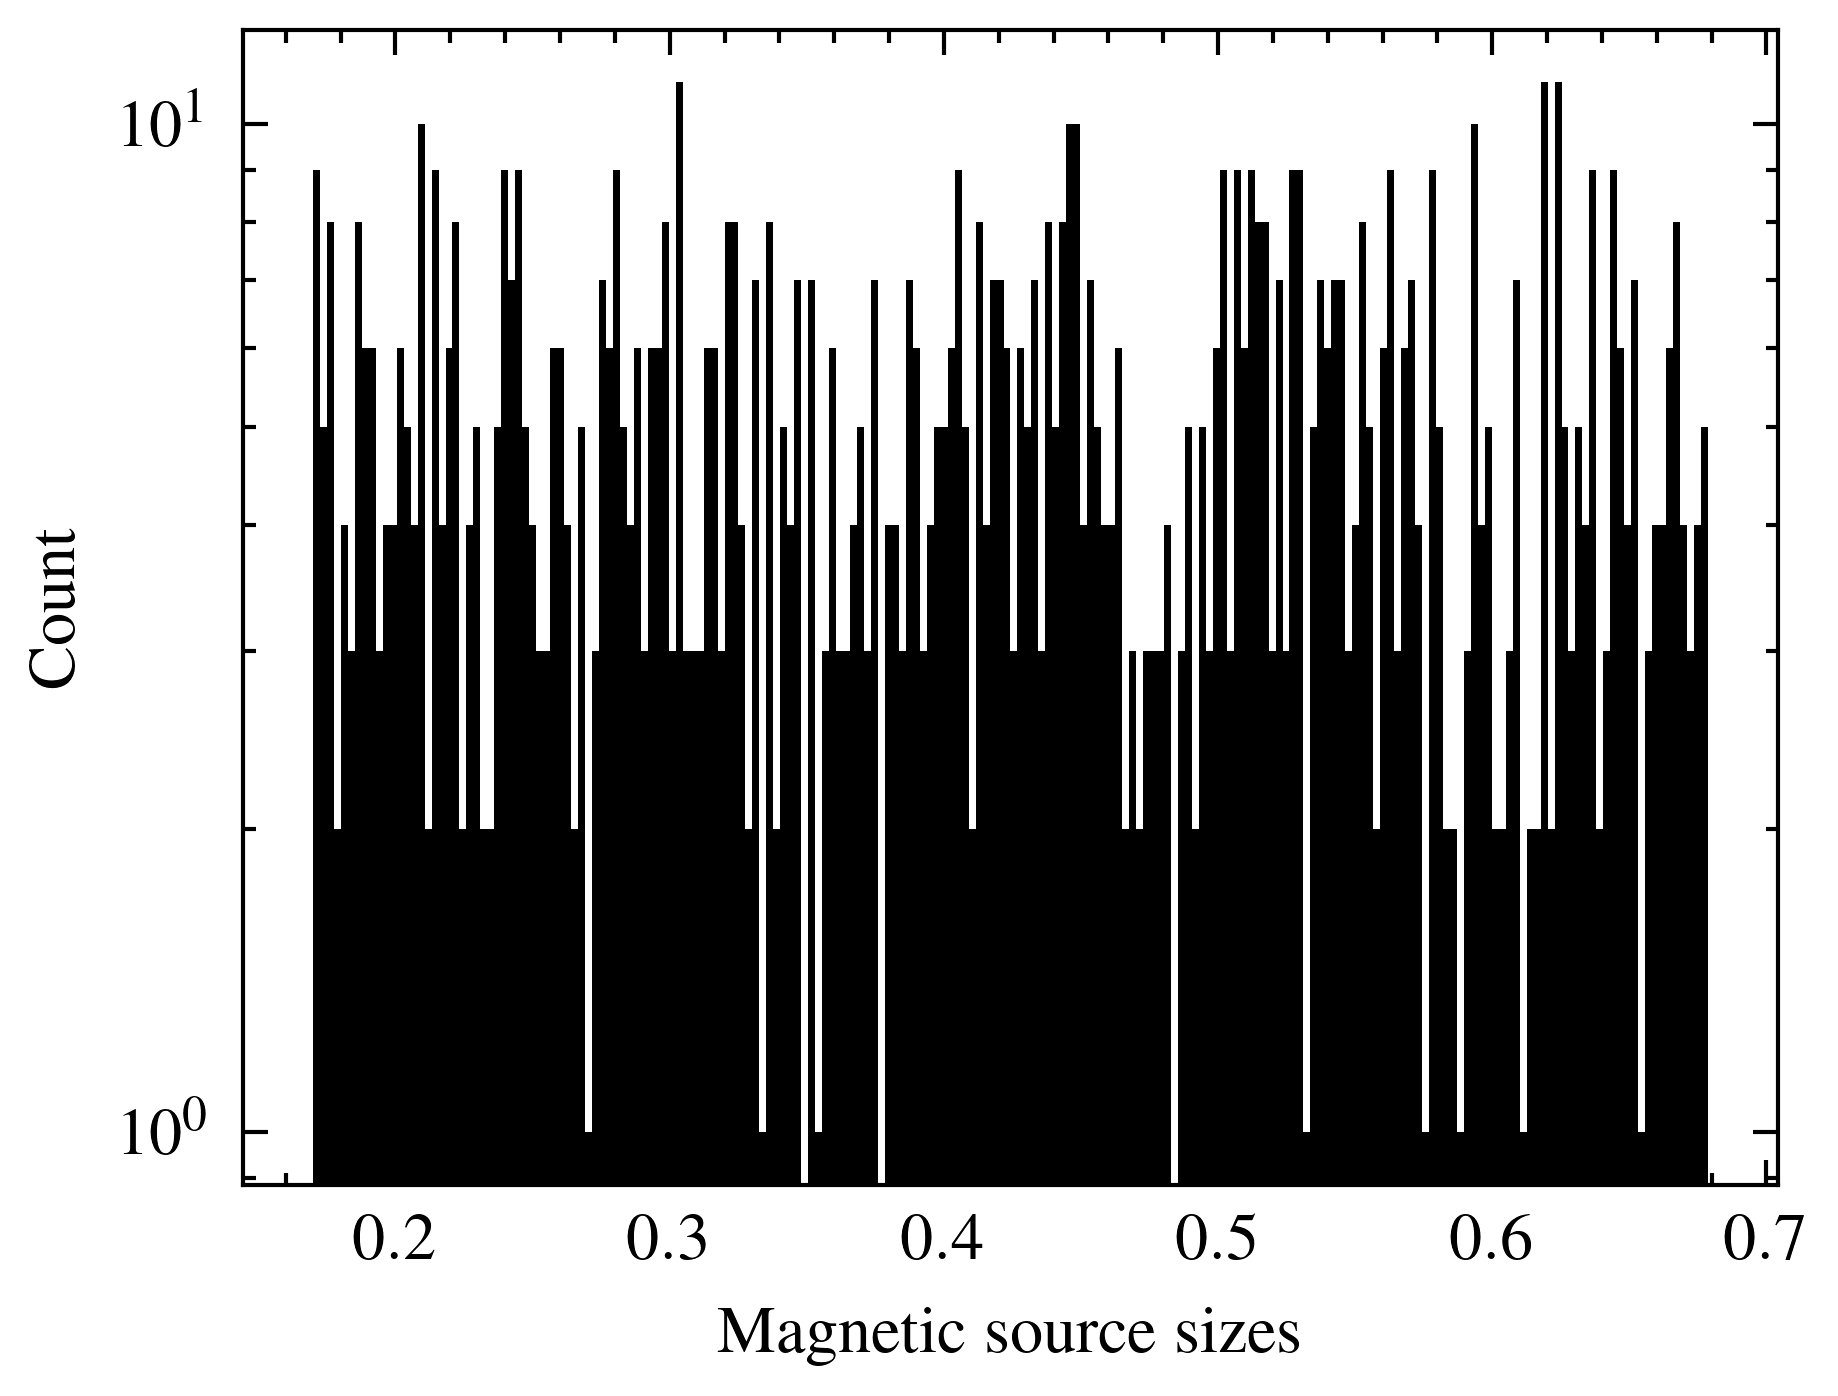

Indices with size == 0: []
Count: 0


In [3]:
# Size overview
sizes = np.linalg.norm(data["sources"][:990,0,6:8], axis=1)
print(np.sort(sizes)[:50])
plt.hist(sizes, bins=200)
plt.yscale("log")
plt.xlabel("Magnetic source sizes")
plt.ylabel("Count")
plt.show()
zero_idxs = np.where(sizes == 0)[0]
print("Indices with size == 0:", zero_idxs)
print("Count:", zero_idxs.size)
if zero_idxs.size:
    print("Example corresponding source entries:")
    print(data["sources"][zero_idxs][:3])

0.96182644 -0.91947323


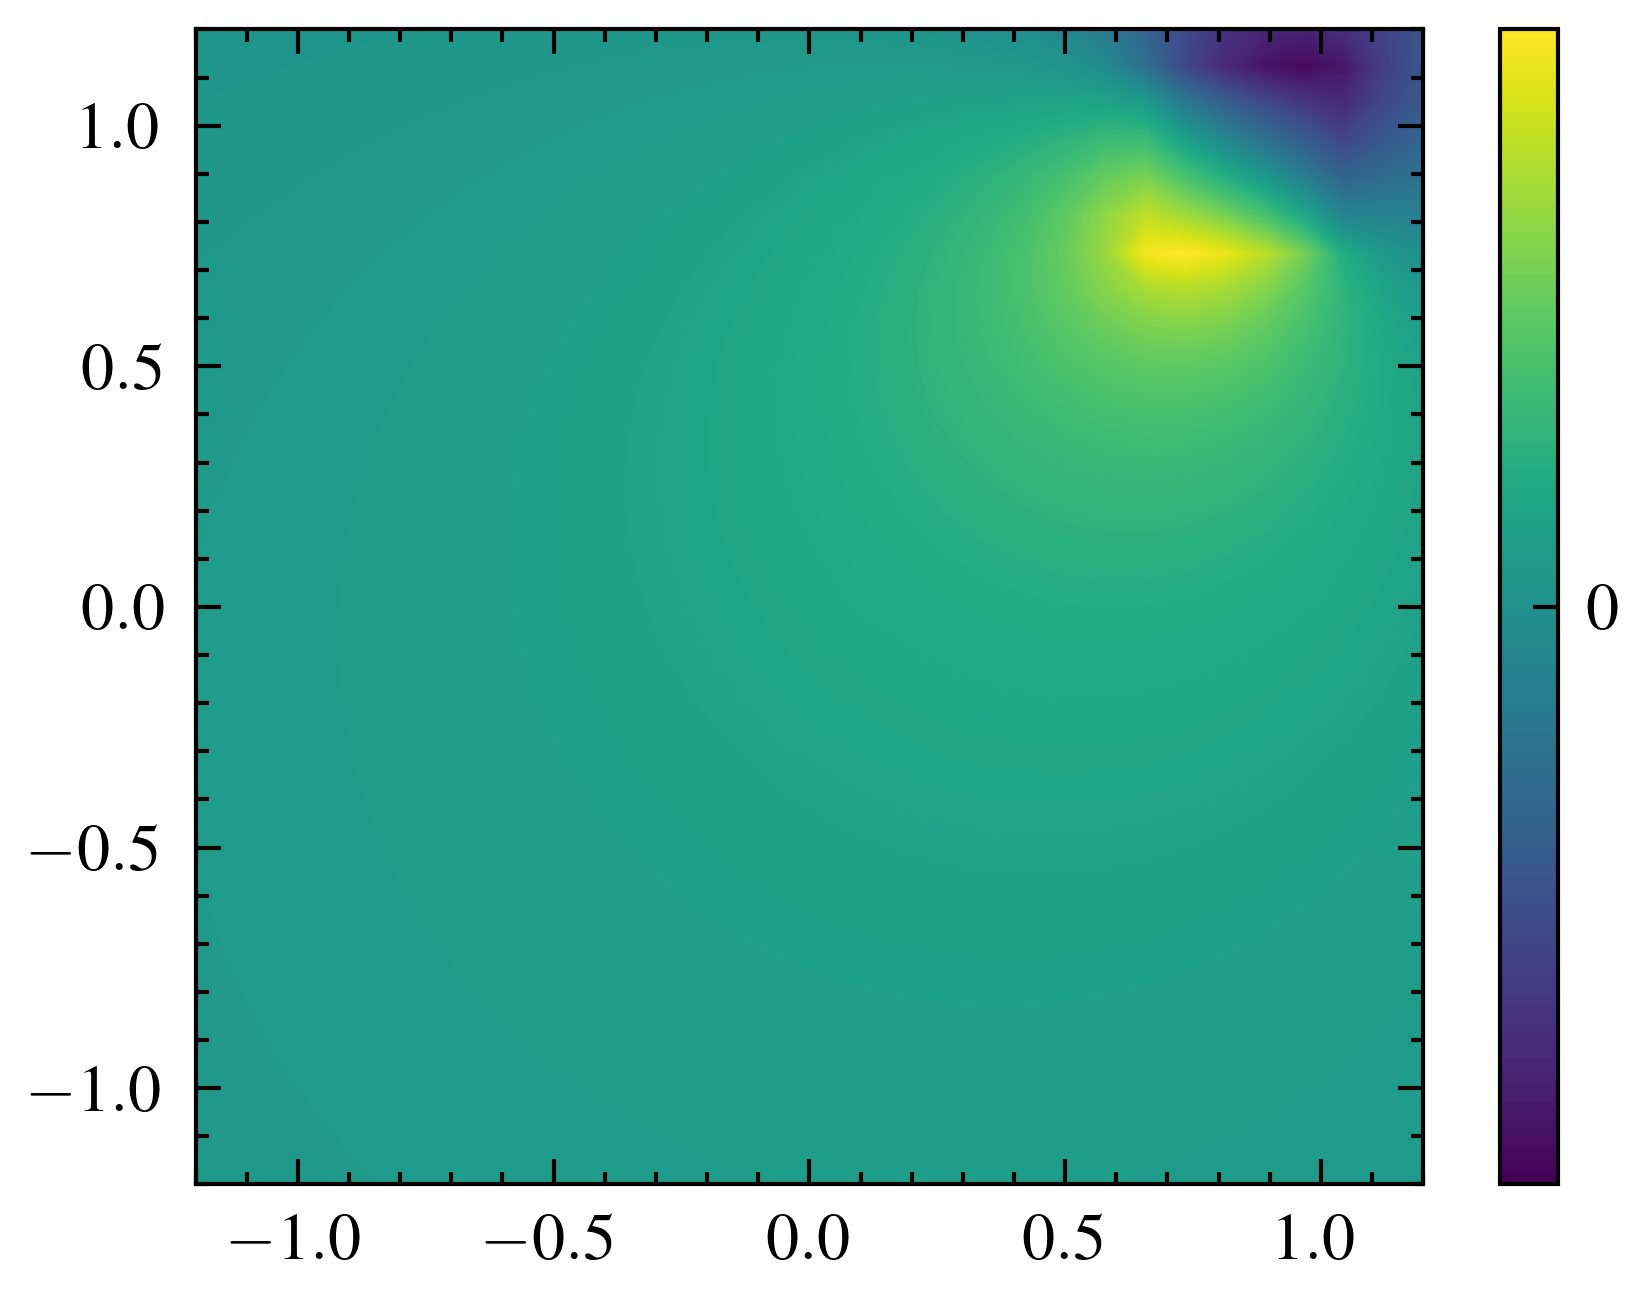

In [4]:
x_grid = np.array(data['grid'][:, 0].reshape((res, res)))
y_grid = np.array(data['grid'][:, 1].reshape((res, res)))
gt_msp = data["msp_grid"][idx].reshape((res, res))
print(gt_msp.max(), gt_msp.min())
max_abs = max(abs(gt_msp.max()), abs(gt_msp.min()))
vmax = max_abs / 10
vmin = -max_abs / 10
cbar_ticks = np.linspace(-int(max_abs)/10, int(max_abs)/10, int(max_abs)*2+1)

# norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
levels = np.linspace(vmin, vmax, 250)  # evenly spaced, symmetric levels
contour = plt.contourf(x_grid, y_grid, np.clip(gt_msp / 10, vmin, vmax), levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)

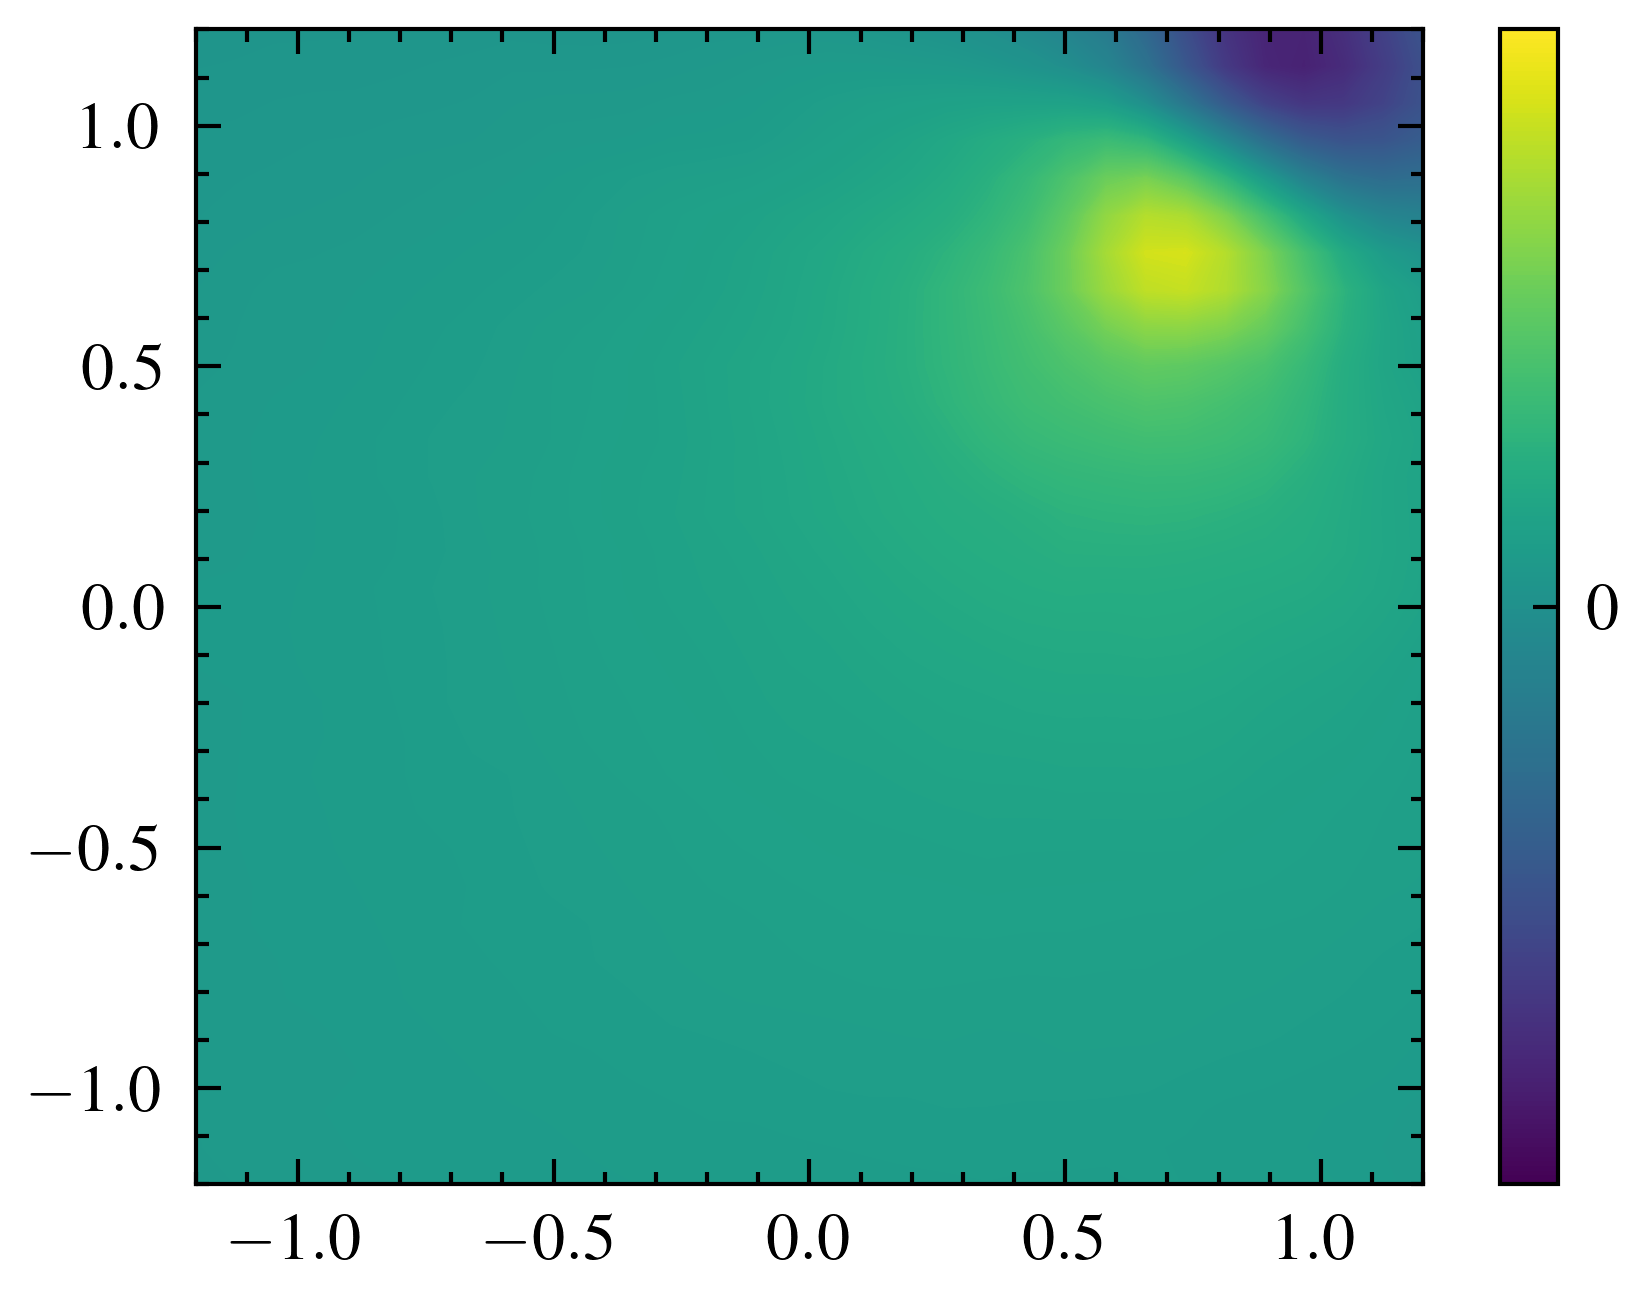

In [5]:
model_cfg = HyperLayer(
    width=400,
    depth=3,
    hwidth=2,
    hdepth=3,
    seed=42,
)

model_folder = Path().resolve() / '..' / 'models'
model_path = f"{model_folder}/fc_ilr_400_200k_res32_large_m.eqx"
model = eqx.tree_deserialise_leaves(model_path, model_cfg)

sim = data.copy()
sim_f = jax.vmap(model, in_axes=(0, None))(data['sources'], data["grid"])

contour = plt.contourf(x_grid, y_grid, sim_f[idx].reshape((res, res))/10, levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)

(990, 1024)


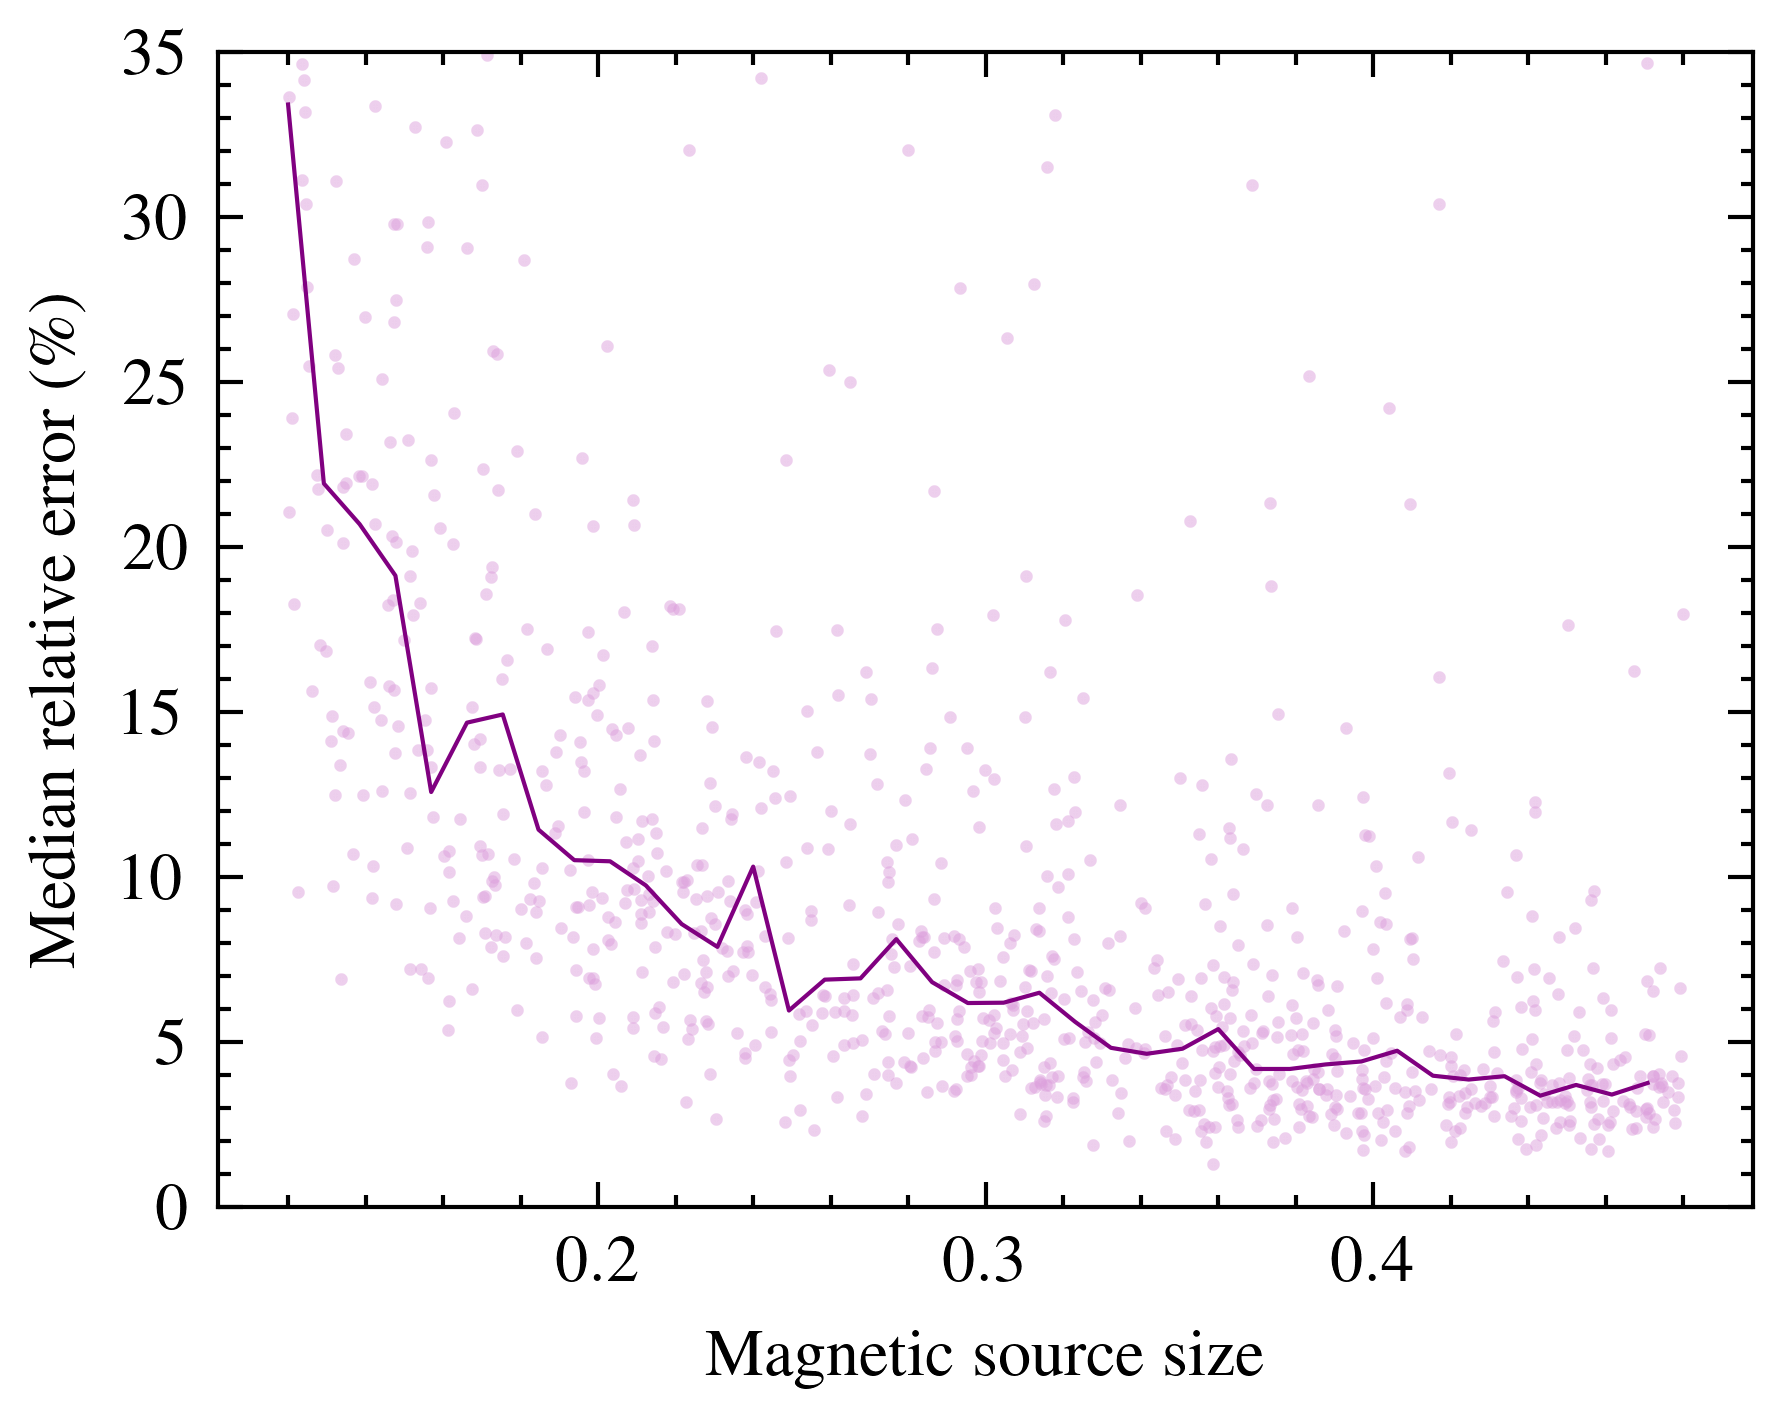

In [6]:
err_fcilr = (np.abs(sim_f[:990] - data["msp_grid"][:990]) / np.abs(data["msp_grid"][:990])) * 100
print(err_fcilr.shape)
m_relerr = np.nanmean(err_fcilr, axis=-1)
plt.plot(data["sources"][:990,0,6], m_relerr, 'o', markersize=0.5, c='plum', alpha=0.5)
# plt.yscale("log")
plt.ylim(0, 35)
plt.xlabel("Magnetic source size")
plt.ylabel("Median relative error (\%)")
# plt.savefig("/home/spol/repos/hypermagnetics/figs/fcilr_relerr_sizes.png", dpi=300)

#: 0: d_size_normed, 1: err, 2: comp
d_err = np.vstack([data["sources"][:990,0,6].flatten(), m_relerr.flatten()]).T

d_bins = np.linspace(0.12, 0.48, 40)
bin_indices = np.digitize(d_err[:,0], d_bins)

bin_medians = []
for i in range(1, len(d_bins)):
    bin_data = d_err[bin_indices == i]
    if bin_data.size > 0:
        bin_medians.append(np.nanmedian(bin_data[:,1]))
    else:
        bin_medians.append(np.nan)
plt.plot(d_bins[:-1], bin_medians, '-', color='purple', linewidth=0.5)
plt.savefig("/home/spol/repos/hypermagnetics/figs/fcilr_relerr_sizes.svg")

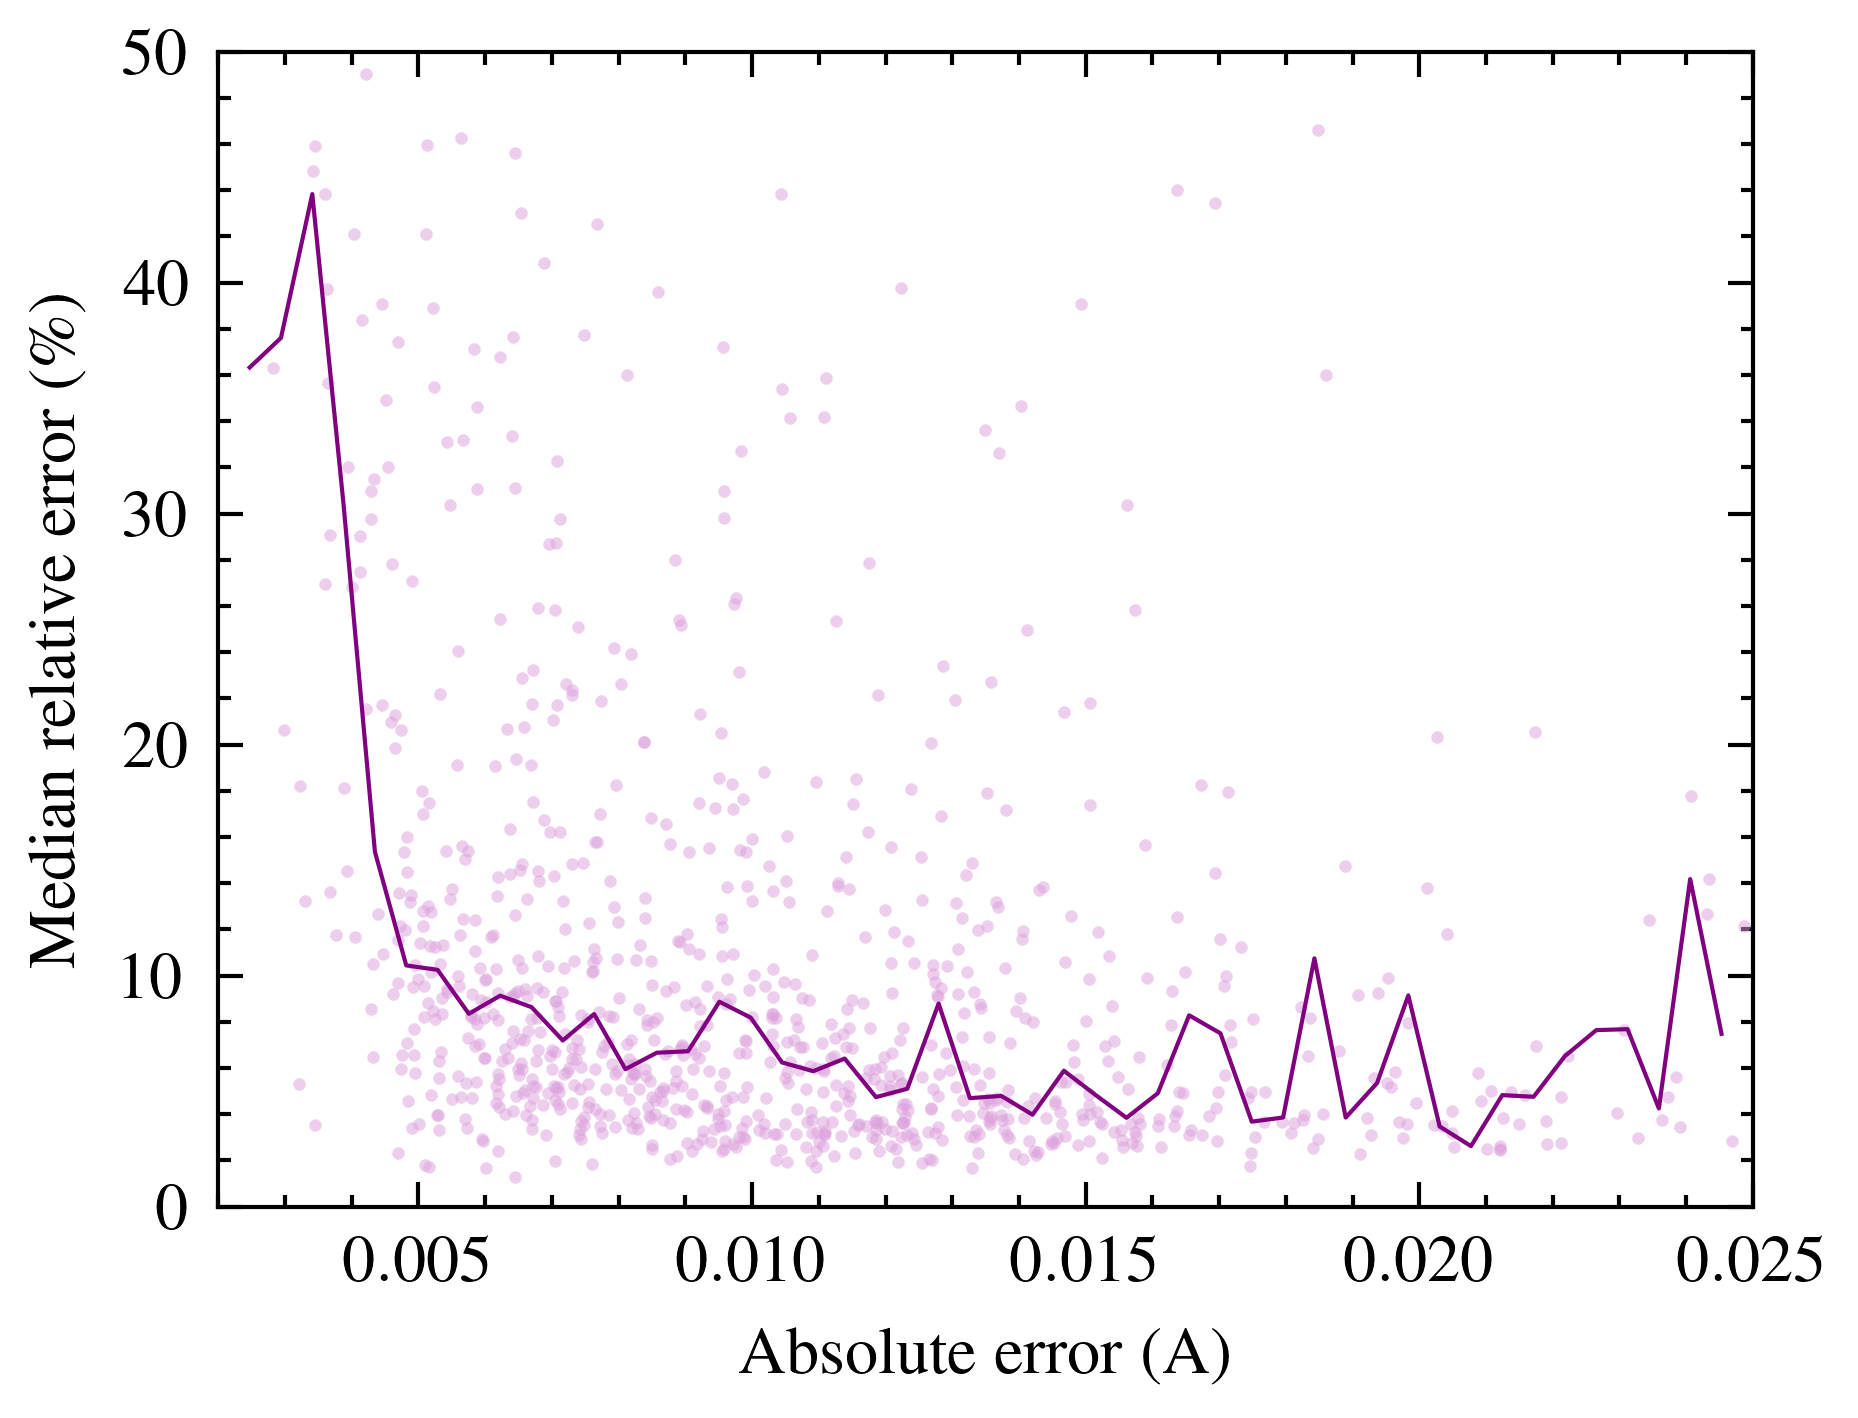

In [29]:
abserr_fcilr = np.abs(sim_f[:990] - data["msp_grid"][:990])
m_abserr = np.nanmean(abserr_fcilr, axis=-1)
plt.plot(m_abserr, m_relerr, 'o', markersize=0.5, c='plum', alpha=0.5)
# plt.xscale("log")
plt.xlim(0.002, 0.025)
plt.ylim(0, 50)
plt.xlabel("Absolute error (A)")
plt.ylabel("Median relative error (\%)")
# plt.savefig("/home/spol/repos/hypermagnetics/figs/fcilr_relerr_sizes.png", dpi=300)

#: 0: d_size_normed, 1: err, 2: comp
d_err = np.vstack([m_abserr.flatten(), m_relerr.flatten()]).T

d_bins = np.linspace(0.002, 0.025, 50)
bin_indices = np.digitize(d_err[:,0], d_bins)

bin_medians = []
for i in range(1, len(d_bins)):
    bin_data = d_err[bin_indices == i]
    if bin_data.size > 0:
        bin_medians.append(np.nanmedian(bin_data[:,1]))
    else:
        bin_medians.append(np.nan)
plt.plot(d_bins[:-1], bin_medians, '-', color='purple', linewidth=0.5)
plt.savefig("/home/spol/repos/hypermagnetics/figs/fcilr_relerr_abserr.svg")

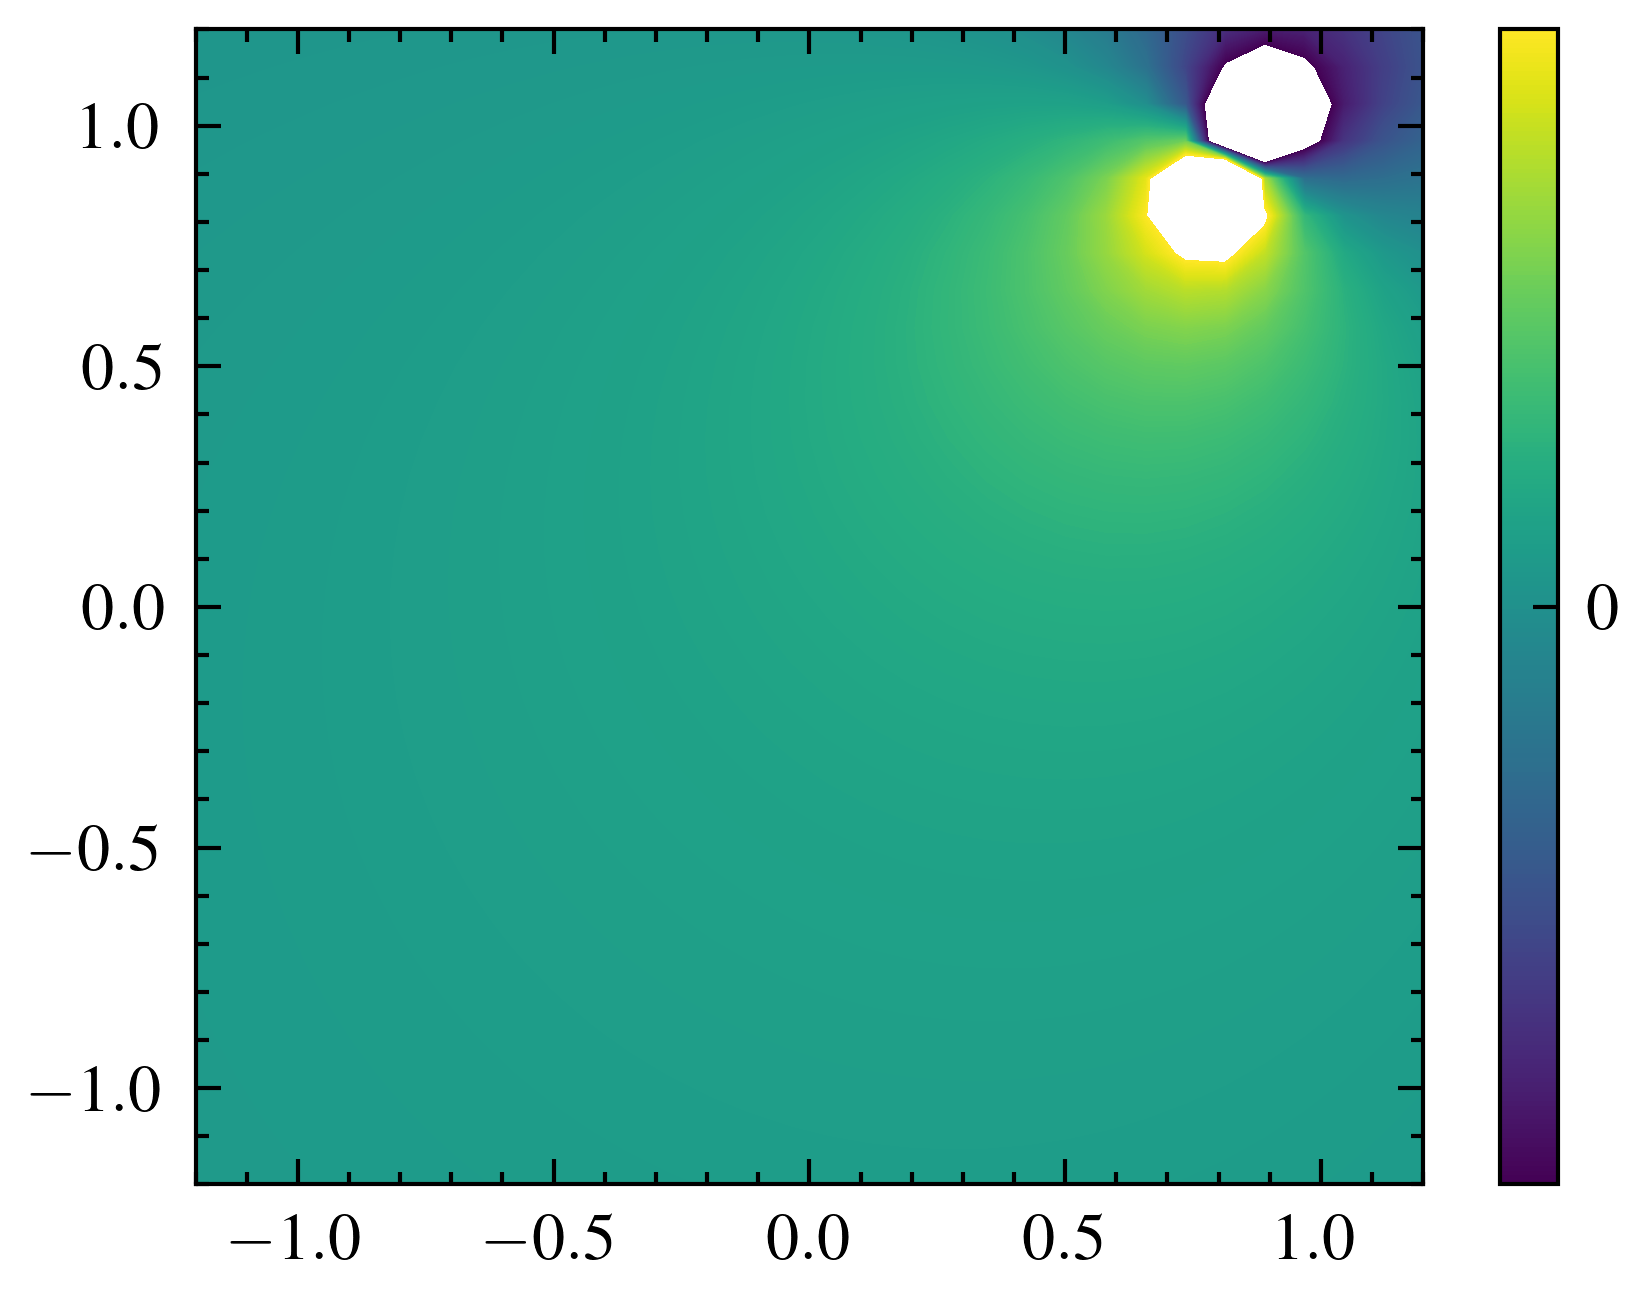

In [7]:
# Potential 2D data
sim = data.copy()
sim_fmm, _, _ = potential2D(data['sources'], sim['shape'], data["grid"], correction_source=True, prism_mt=True)

contour = plt.contourf(x_grid, y_grid, sim_fmm[idx].reshape((res, res))/10, levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)

[[-4.5322194  -7.89246     0.          0.8373987   0.93912244  0.
   0.19954468  0.19954468 10.        ]]


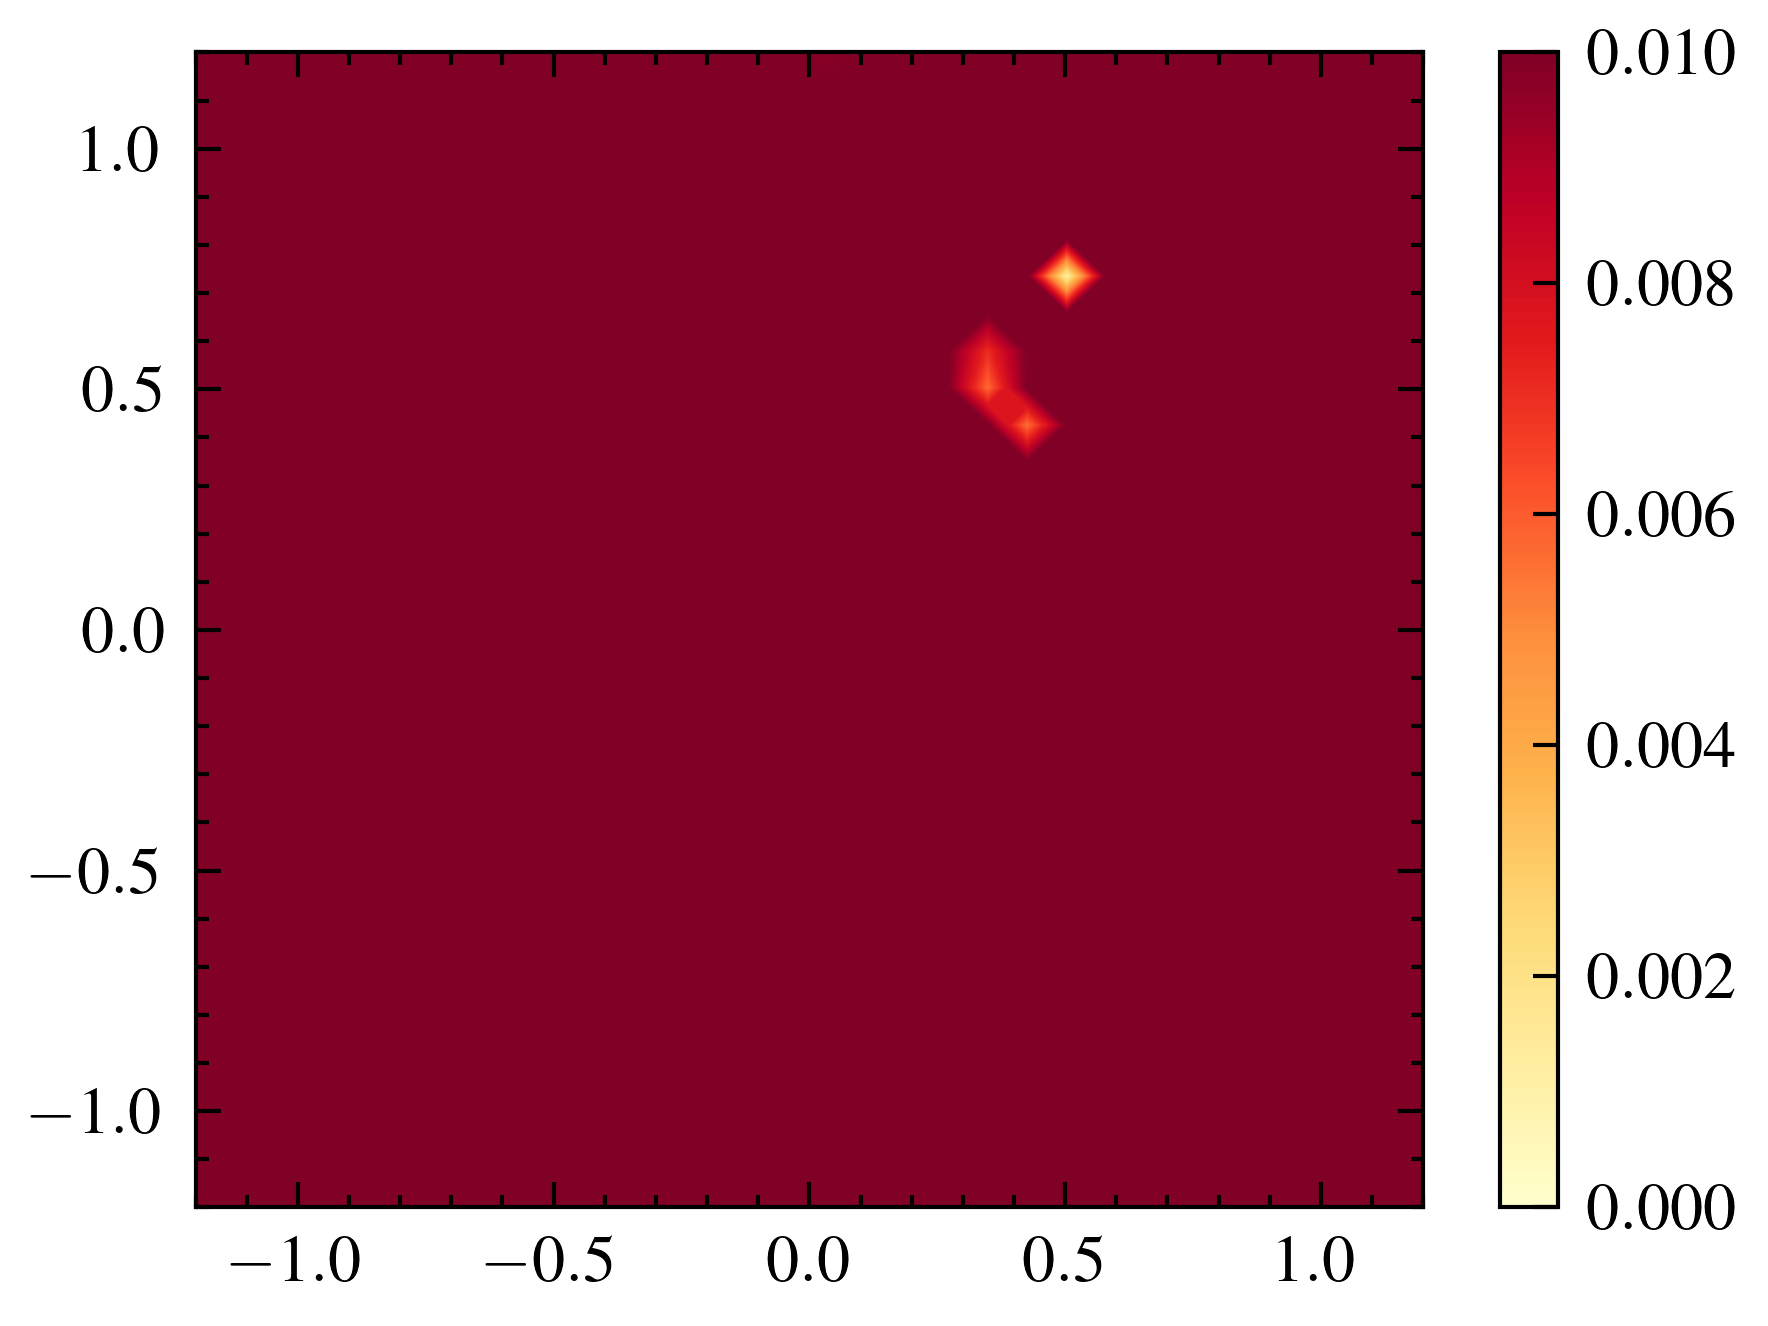

In [8]:
err = (np.abs(sim_fmm[idx] - data["msp_grid"][idx]) / np.abs(data["msp_grid"][idx])) * 100
vmax_rel = 0.01
print(data["sources"][idx])
levels_rel = np.linspace(0, vmax_rel, 250)  # evenly spaced, symmetric levels
contour_rel = plt.contourf(x_grid, y_grid, np.clip(err, 0, vmax_rel).reshape((res, res)), cmap="YlOrRd", levels=levels_rel)
cbar = plt.colorbar(contour_rel)
cbar_ticks_rel = np.linspace(0, vmax_rel, 5 + 1)
cbar.set_ticks(cbar_ticks_rel)

(990, 1024)


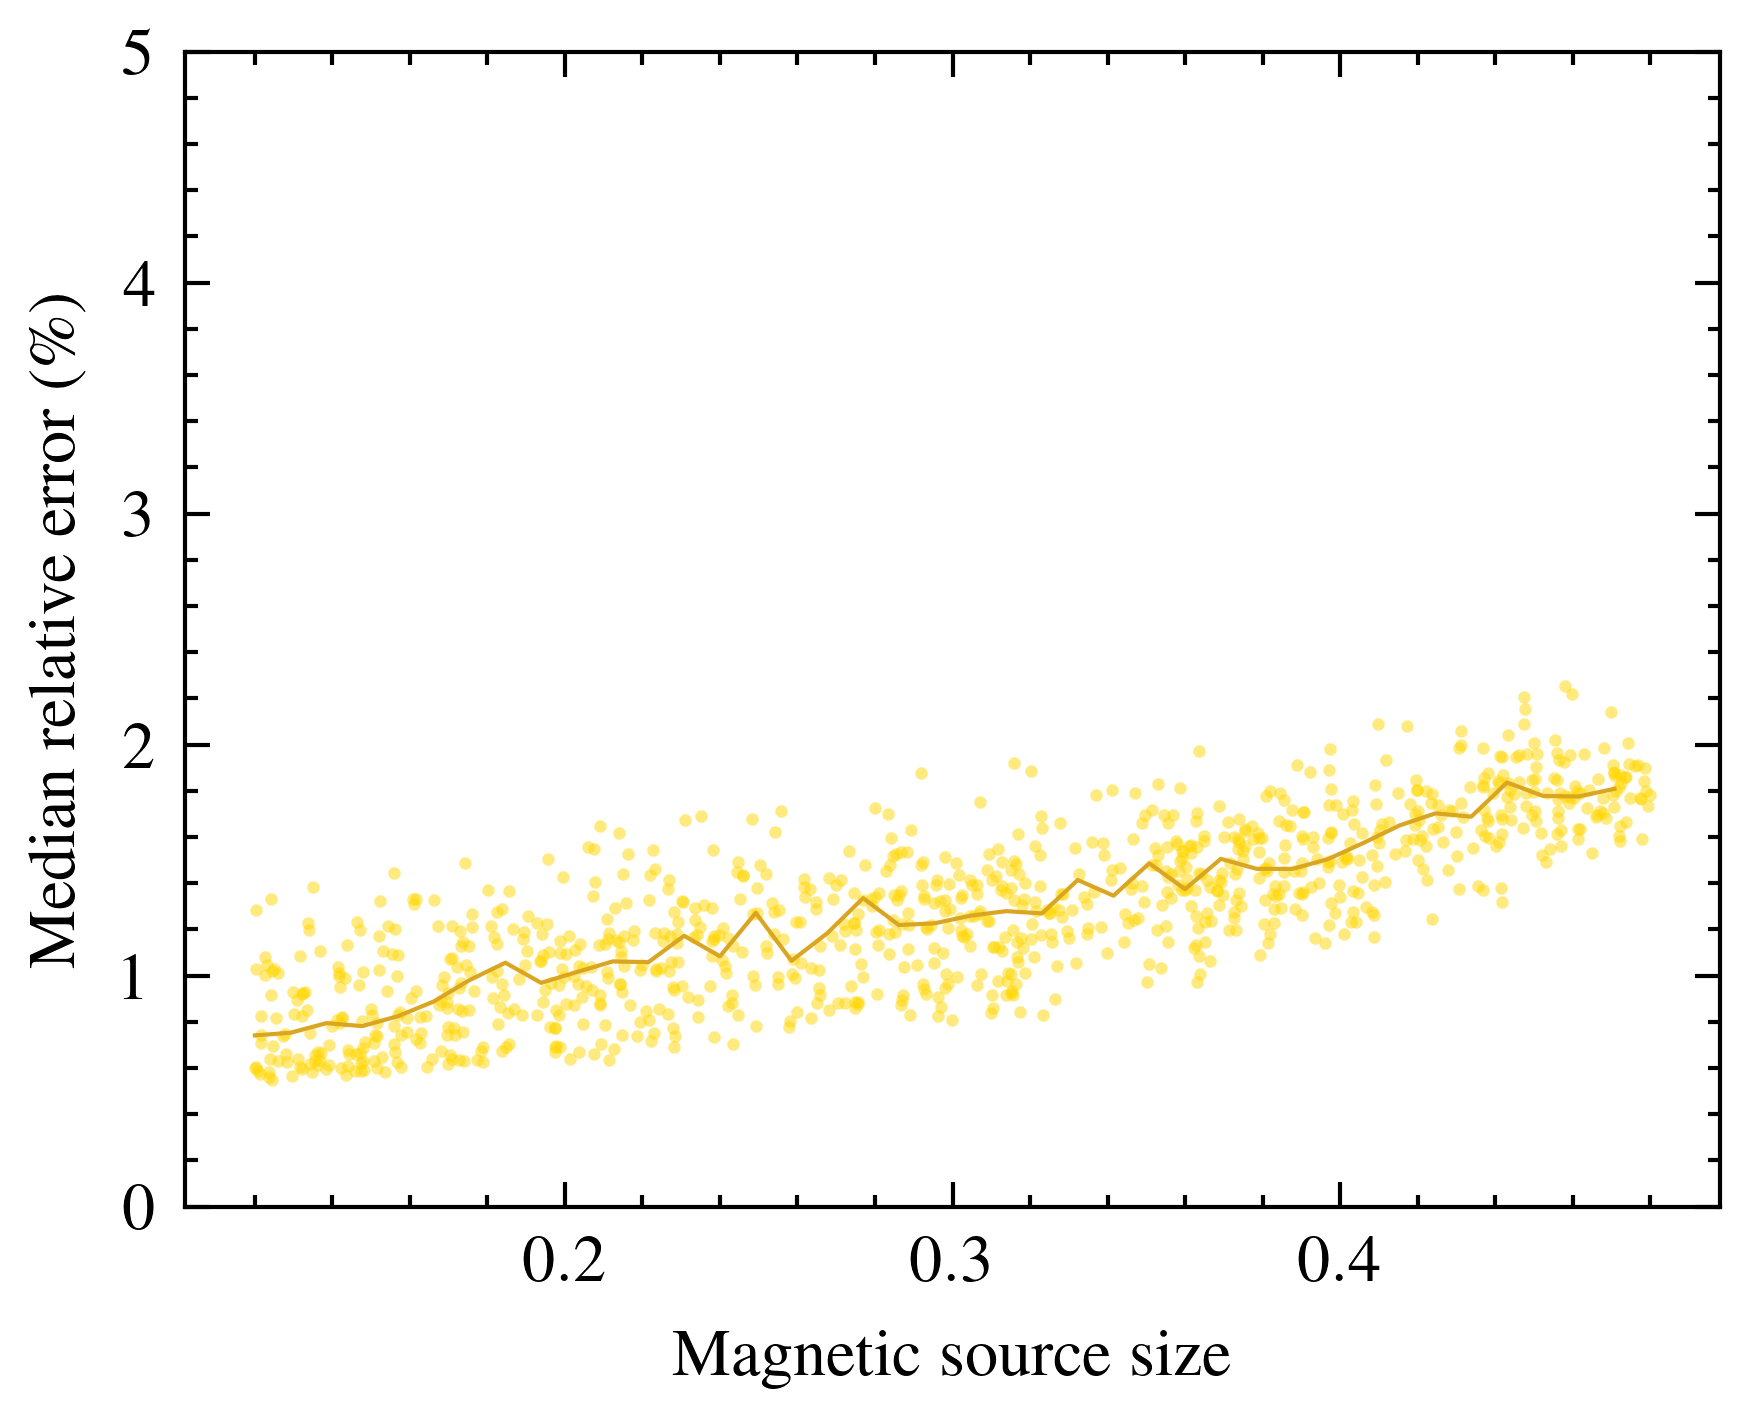

In [9]:
# Prepare FMM2D error analysis
err_fmm = (np.abs(sim_fmm[:990] - data["msp_grid"][:990]) / np.abs(data["msp_grid"][:990])) * 100
print(err_fmm.shape)
m_relerr_fmm = np.nanmedian(err_fmm, axis=-1)

plt.plot(data["sources"][:990,0,6], m_relerr_fmm, 'o', markersize=0.5, c='gold', alpha=0.5)
# plt.yscale("log")
plt.ylim(0, 5)
plt.xlabel("Magnetic source size")
plt.ylabel("Median relative error (\%)")
# plt.savefig("/home/spol/repos/hypermagnetics/figs/fcilr_relerr_sizes.png", dpi=300)

#: 0: d_size_normed, 1: err, 2: comp
d_err = np.vstack([data["sources"][:990,0,6].flatten(), m_relerr_fmm.flatten()]).T

d_bins = np.linspace(0.12, 0.48, 40)
bin_indices = np.digitize(d_err[:,0], d_bins)

bin_medians = []
for i in range(1, len(d_bins)):
    bin_data = d_err[bin_indices == i]
    if bin_data.size > 0:
        bin_medians.append(np.nanmedian(bin_data[:,1]))
    else:
        bin_medians.append(np.nan)
plt.plot(d_bins[:-1], bin_medians, '-', color='goldenrod', linewidth=0.5)
plt.savefig("/home/spol/repos/hypermagnetics/figs/fmm_relerr_sizes.svg")

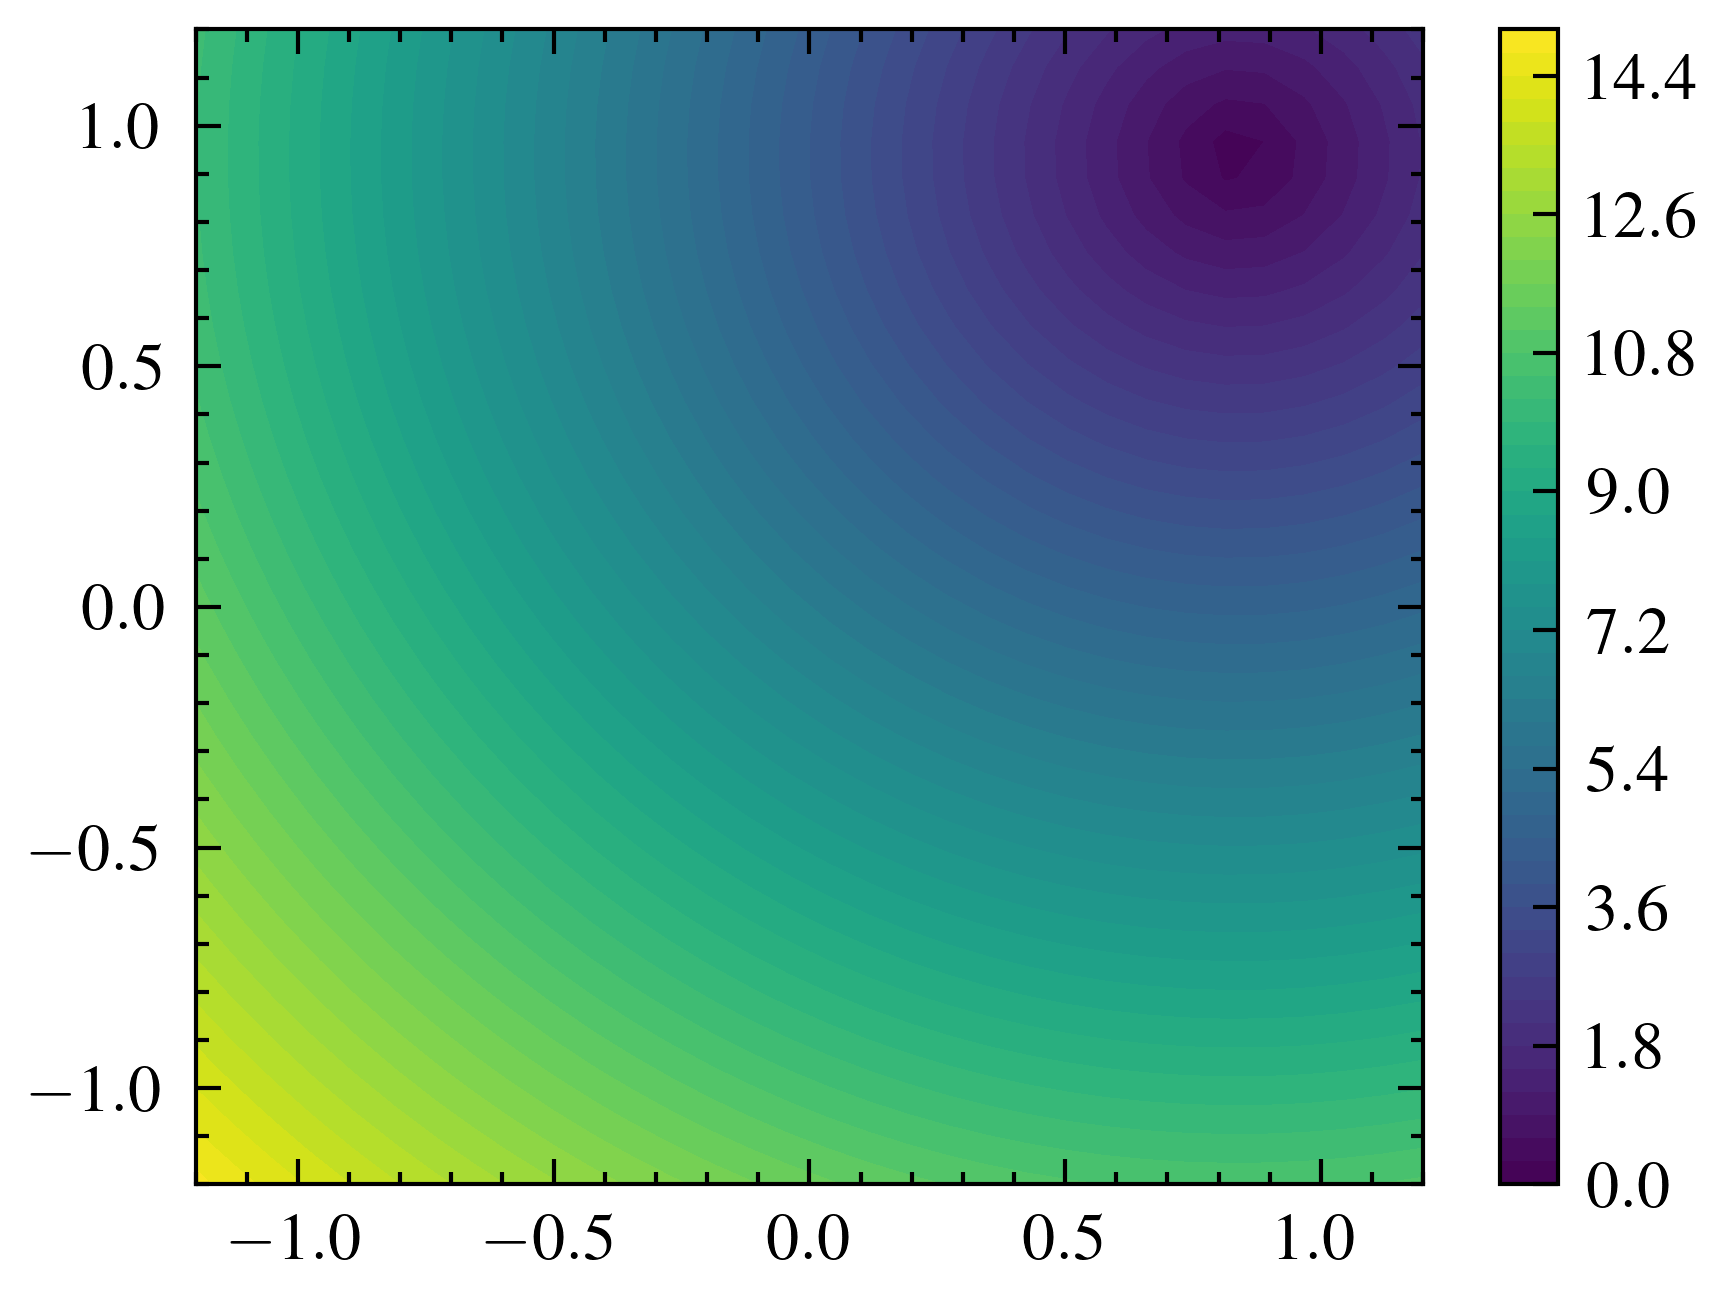

In [10]:
distances = np.linalg.norm((np.repeat(data["grid"][None, :, :], 990, axis=0) - data["sources"][:990,0,3:6][:, None, :]), axis=-1)
d_size = distances / data["sources"][:990,0,6][:, None]
plt.contourf(x_grid, y_grid, d_size[idx].reshape((res, res)), levels=50)
plt.colorbar()

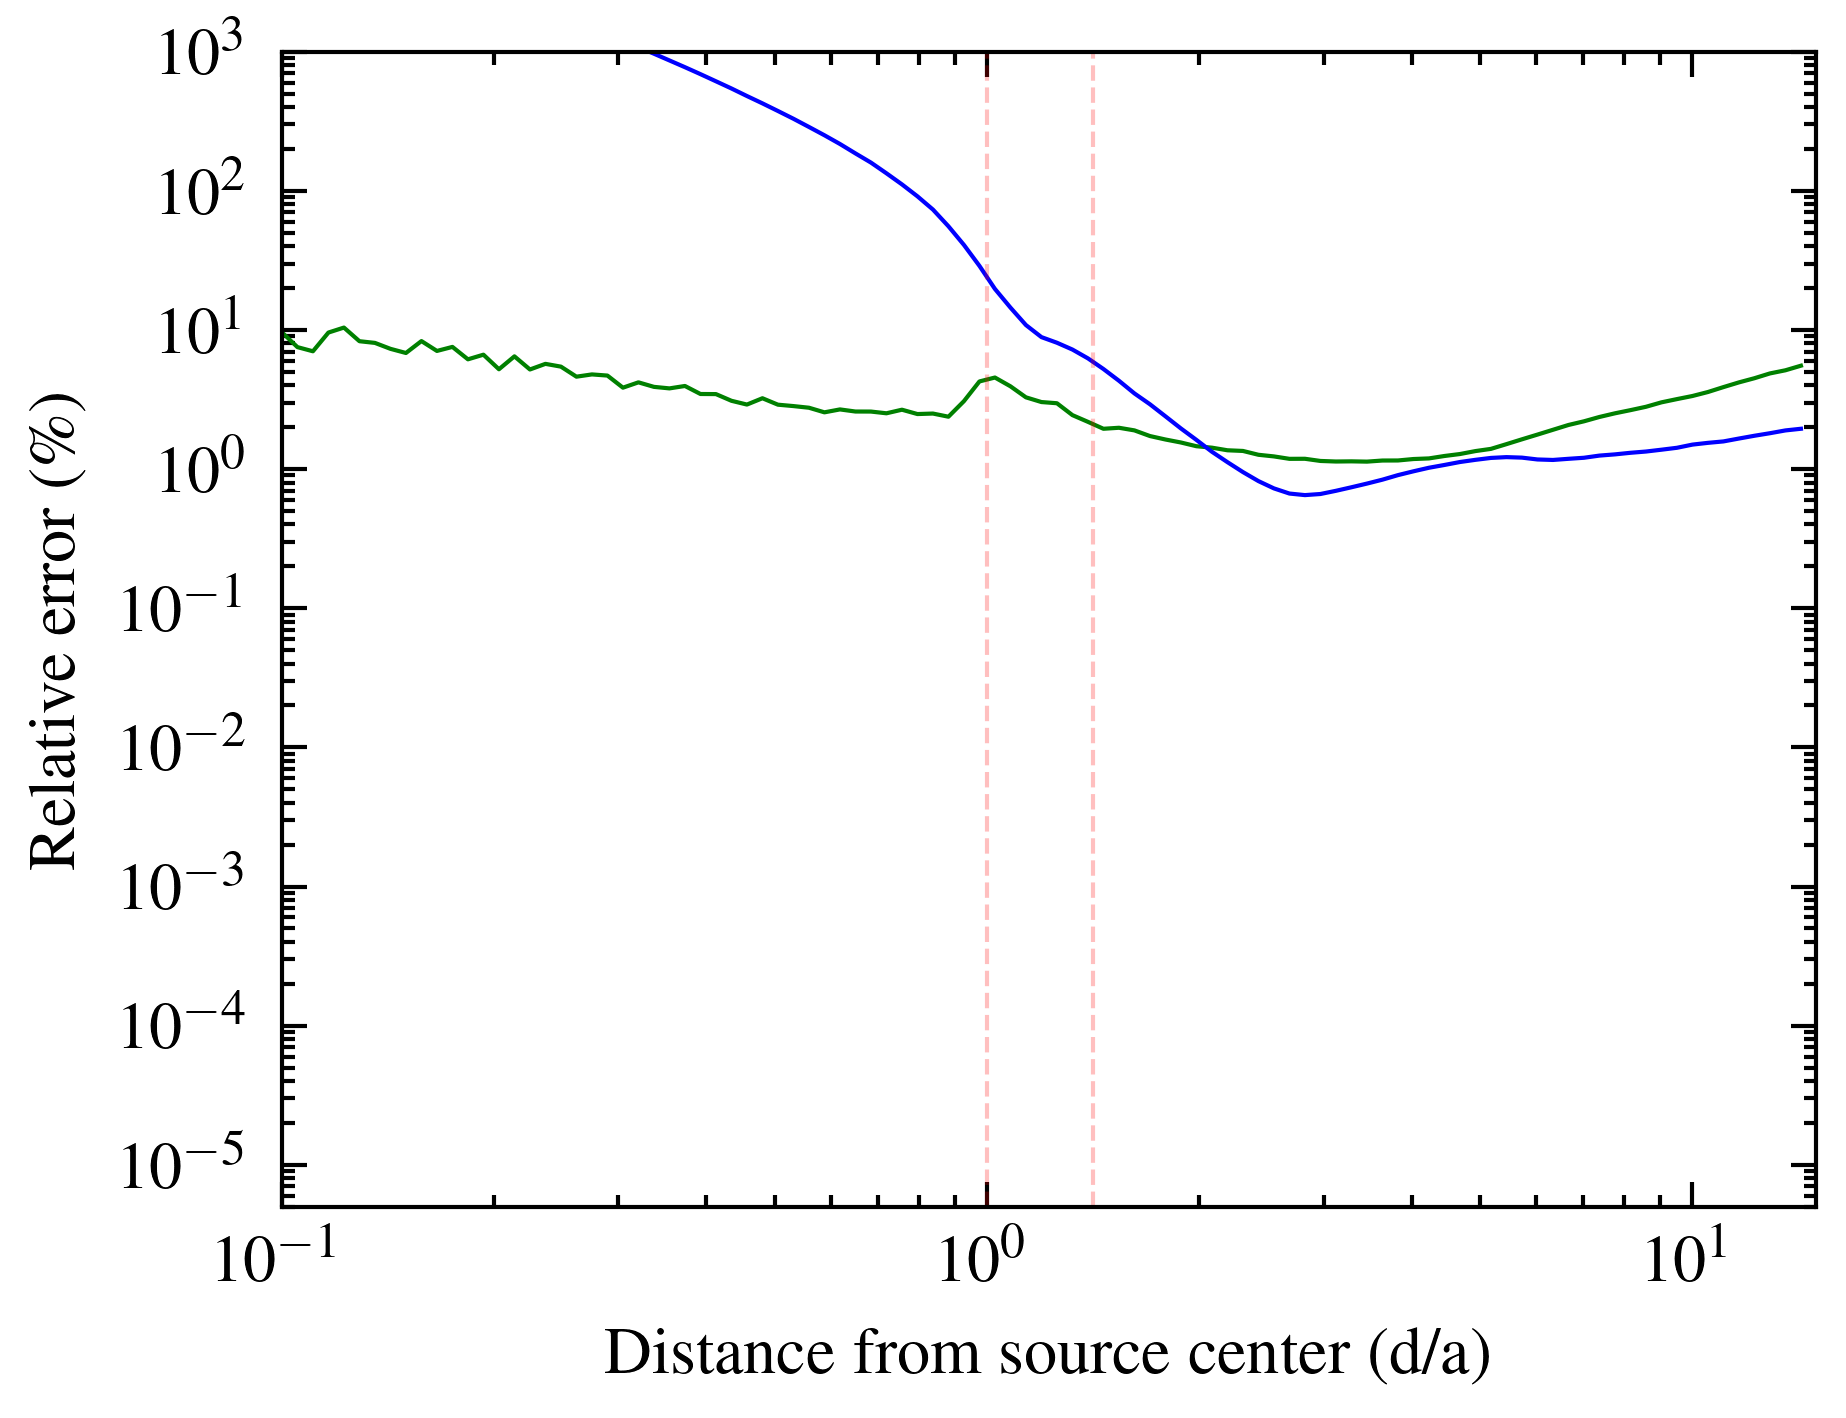

In [11]:
a = data["sources"][:990,0,6:8]
m = data["sources"][:990,0,0:3]
r0 = data["sources"][:990,0,3:6]
comp_var = m
comp = np.repeat(np.linalg.norm(comp_var, axis=-1)[:, None], res**2, axis=-1)
# plt.scatter(d_size.flatten(), err_fcilr.flatten(), s=0.1, edgecolors='none', c='plum', alpha=0.1) # c=comp.flatten(), cmap="magma")
# plt.scatter(d_size.flatten(), err_fmm.flatten(), s=0.1, edgecolors='none', c='gold', alpha=0.1) # c=comp.flatten(), cmap="magma")
# plt.colorbar()

#: 0: d_size_normed, 1: err, 2: comp
d_err = np.vstack([d_size.flatten(), err_fcilr.flatten(), comp.flatten()]).T
d_err_fmm = np.vstack([d_size.flatten(), err_fmm.flatten(), comp.flatten()]).T

d_bins = np.linspace(np.log(1e-1), np.log(15), 100)
bin_indices = np.digitize(d_err[:,0], np.exp(d_bins))
bin_indices_fmm = np.digitize(d_err_fmm[:,0], np.exp(d_bins))

bin_medians = []
bin_medians_fmm = []
bin_smallest = []
bin_largest = []
for i in range(1, len(d_bins)):
    bin_data = d_err[bin_indices == i]
    bin_data_fmm = d_err_fmm[bin_indices_fmm == i]
    if bin_data.size > 0:
        bin_medians.append(np.nanmedian(bin_data[:,1]))
        bin_medians_fmm.append(np.nanmedian(bin_data_fmm[:,1]))
        bin_smallest.append(np.nanmedian(bin_data[:,1][bin_data[:,2] <= 3]))
        bin_largest.append(np.nanmedian(bin_data[:,1][bin_data[:,2] >= 20]))
    else:
        bin_medians.append(np.nan)
        bin_medians_fmm.append(np.nan)
        bin_smallest.append(np.nan)
        bin_largest.append(np.nan)
plt.plot(np.exp(d_bins[:-1]), bin_medians, '-', color='green', linewidth=0.5)
plt.plot(np.exp(d_bins[:-1]), bin_medians_fmm, '-', color='blue', linewidth=0.5)
plt.axvline(1, color='red', linestyle='--', linewidth=0.5, alpha=0.25)
plt.axvline(np.sqrt(2), color='red', linestyle='--', linewidth=0.5, alpha=0.25)
# plt.plot(d_bins[:-1], bin_smallest, '--', color='black', linewidth=0.5)
# plt.plot(d_bins[:-1], bin_largest, '--', color='orange', linewidth=0.5)
plt.yscale("log")
plt.ylim(5e-6, 1e3)
plt.xscale("log")
plt.xlim(1e-1, 15)
plt.xlabel("Distance from source center (d/a)")
plt.ylabel("Relative error (\\%)")
plt.savefig("/home/spol/repos/hypermagnetics/figs/fcilr_relerr_sizes_dist_mean_line_nocorr.svg")


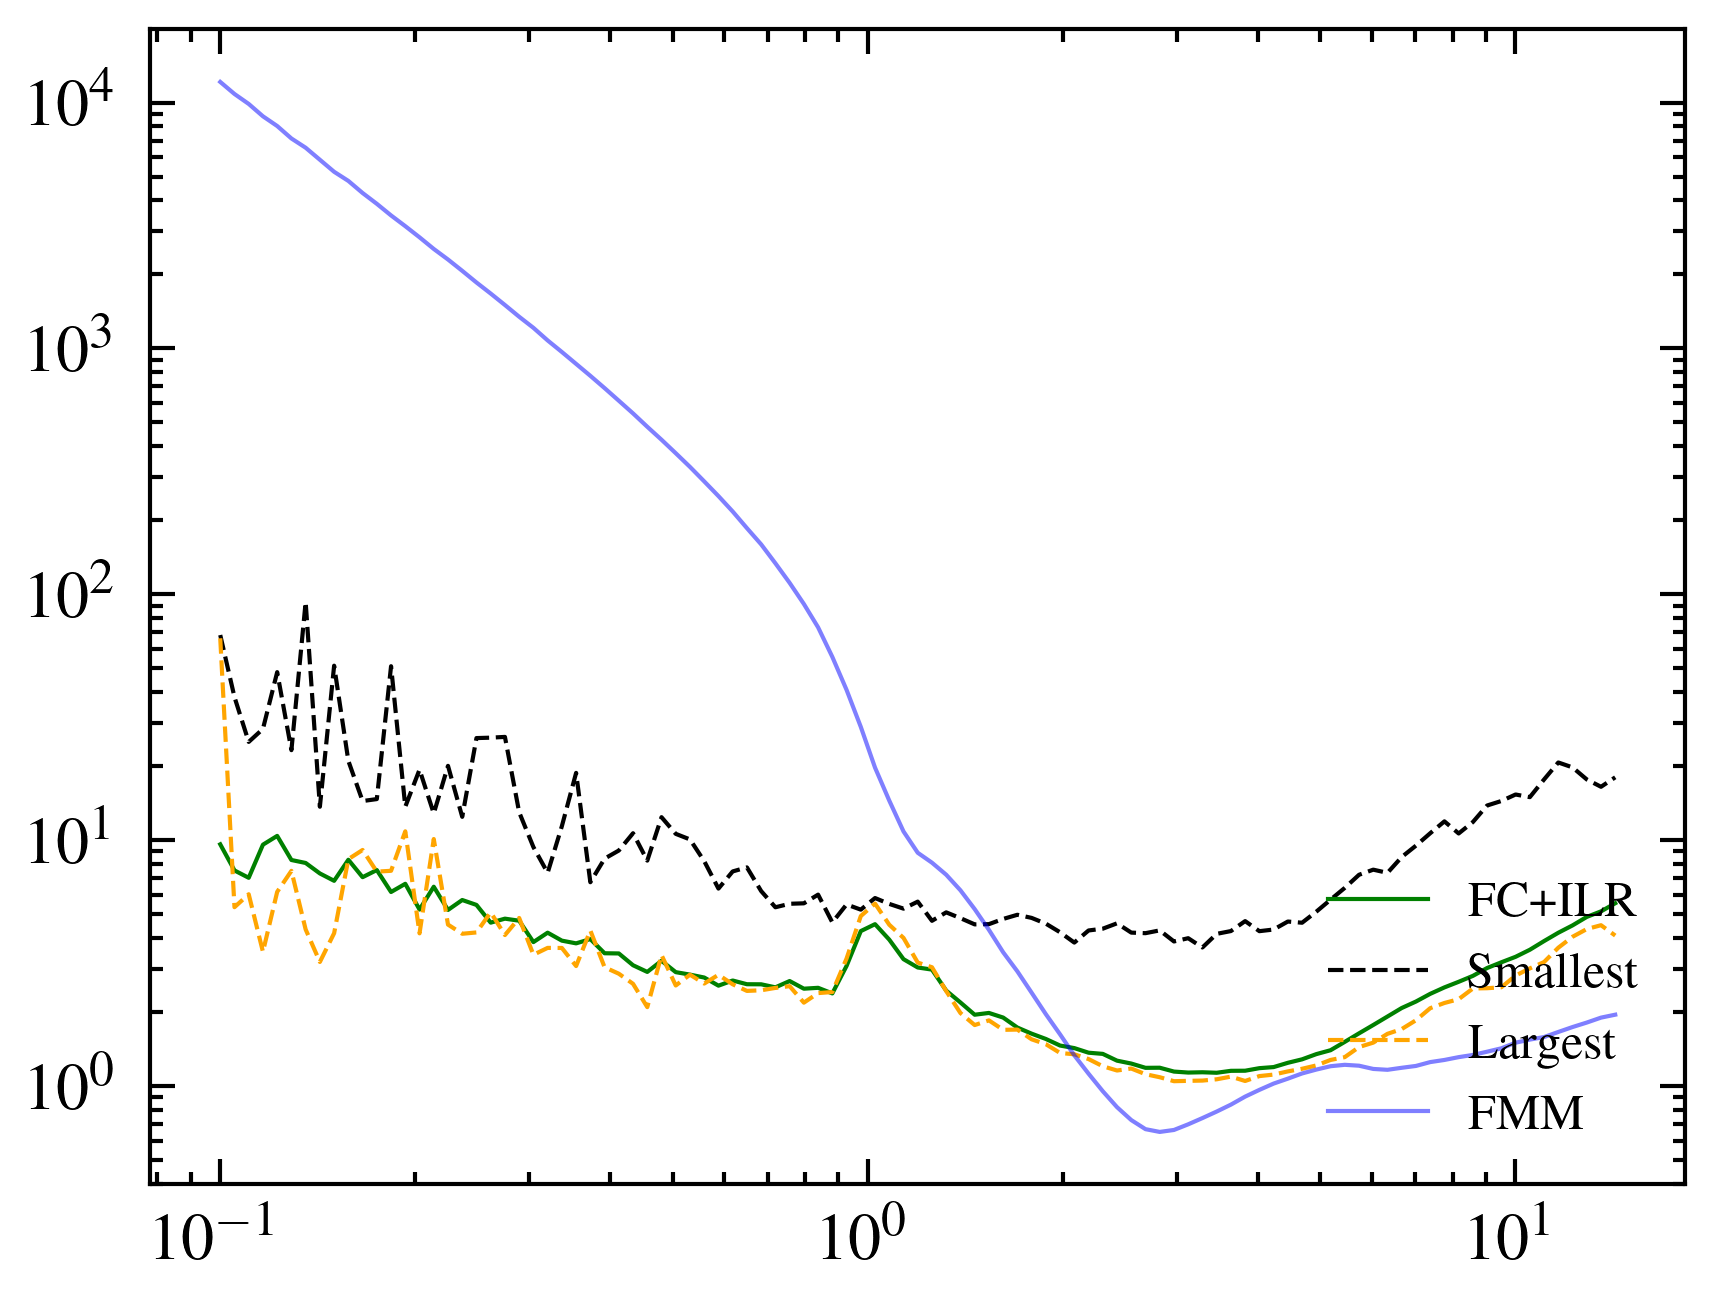

In [12]:
plt.plot(np.exp(d_bins[:-1]), bin_medians, '-', color='green', linewidth=0.5)
plt.plot(np.exp(d_bins[:-1]), bin_smallest, '--', color='black', linewidth=0.5)
plt.plot(np.exp(d_bins[:-1]), bin_largest, '--', color='orange', linewidth=0.5)
plt.plot(np.exp(d_bins[:-1]), bin_medians_fmm, '-', color='blue', linewidth=0.5, alpha=0.5)
plt.yscale("log")
plt.xscale("log")

plt.legend(["FC+ILR", "Smallest", "Largest", "FMM"], loc="lower right", fontsize=6)